# Basic signals

**Aluno:** Murilo &nbsp;|&nbsp; INF0413 - Processamento Digital de Sinais, 2026-2

Nesta atividades criaremos a nossa primeira **biblioteca de sinais digitais** com os sinais:

1. Delta: $\delta[n]$
2. Degrau: $u[n]$
3. Oscilação (periódico): $A \sin(\omega n + \phi)$
4. Exponencial
5. Aleatório (estocástico)


## Sinal delta, ou "impulso" - $\delta[n]$

<div style="text-align: center;">
    <img src="./figures/delta.png" alt="" width="500"/>
</div>


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('.')
from lib.myPlotLib import *

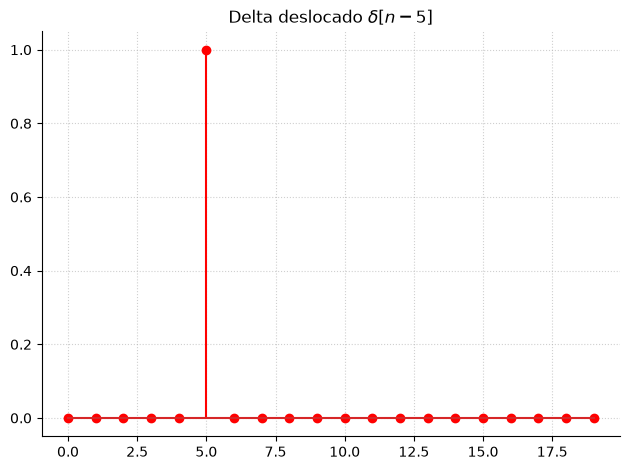

In [2]:
# 1. Sinal delta (v1.0) - Usando numpy
N     = 20                # numero de amostras
xn    = np.zeros(N)       # comeca tudo zerado
k     = 5                 # delay
xn[k] = 1                 # x[n-k]: so a posicao k vale 1

# v2.0 - Usando listas
xn    = [0] * N
xn[k] = 1
xn    = np.array(xn)

# Vetor de amostras
n     = np.arange(N)      # n = 0, 1, 2, ..., N-1

fig, ax = plt.subplots()
ax.stem(n, xn, 'r')
ax.set_title(r'Delta deslocado $\delta[n-5]$')
figureFormat(ax, fig, tight=True)
plt.show()

## Sinal degrau - $u[n]$

<div style="text-align: center;">
    <img src="./figures/step.png" alt="" width="500"/>
</div>


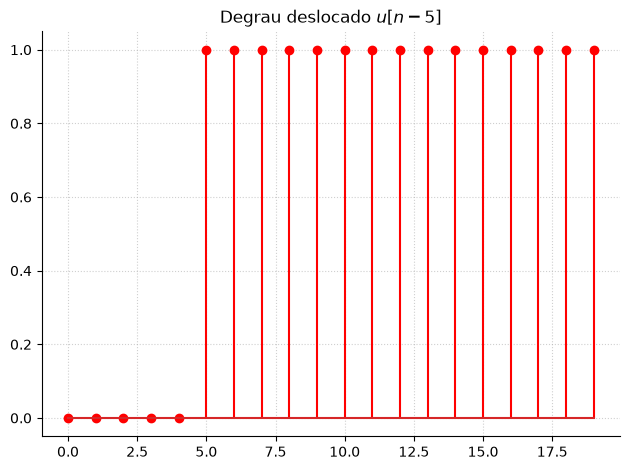

In [3]:
# 2. Degrau (v1.0) - Usando numpy
un      = np.zeros(N)
un[k:]  = 1               # a partir de k, tudo vale 1 -> u[n-k]

# v2.0 - Usando listas
un = [0] * k + [1] * (N - k)
un = np.array(un)

# Vetor de amostras
n  = np.arange(N)

fig, ax = plt.subplots()
ax.stem(n, un, 'r')
ax.set_title(r'Degrau deslocado $u[n-5]$')
figureFormat(ax, fig, tight=True)
plt.show()

## Sinal oscilatório, ou periódico - $A \sin(\omega n + \phi)$

<div style="text-align: center;">
    <img src="./figures/sine.png" alt="" width="500"/>
</div>


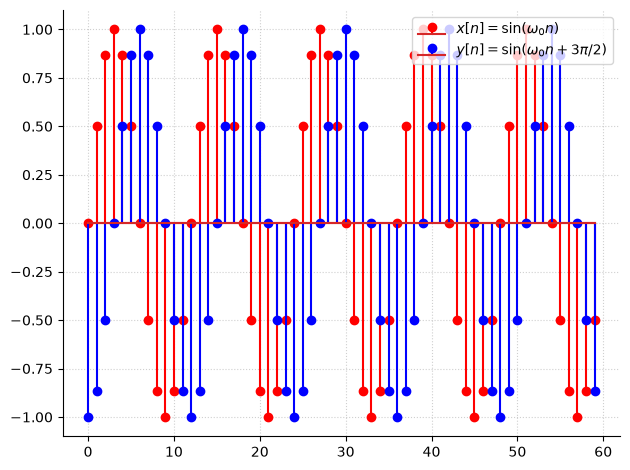

Periodo P = 12 amostras  ->  frequencia digital wo = 2*pi/P = 0.5236 rad/amostra


In [4]:
# 4. Sinal periodico
N  = 60             # numero de amostras
k  = 0              # delay
n  = np.arange(N)   # vetor de amostras

A   = 1                 # amplitude
P   = 12                # periodo do sinal (em amostras)
wo  = 2 * np.pi / P     # frequencia digital (rad/amostra)
phi = 0                 # fase
xn  = A * np.sin(wo * (n - k) + phi)
yn  = A * np.sin(wo * (n - k) + phi + 3*np.pi/2)   # mesma senoide, defasada de 3pi/2 (= um cosseno negativo)

# Plotagem
fig, ax = plt.subplots()
ax.stem(n, xn, 'ro', label=r'$x[n] = \sin(\omega_0 n)$')
ax.stem(n, yn, 'bd', label=r'$y[n] = \sin(\omega_0 n + 3\pi/2)$')
ax.legend(loc='upper right')
# plt.xlim([0, 20])
figureFormat(ax, fig, tight=True)
plt.show()

print(f'Periodo P = {P} amostras  ->  frequencia digital wo = 2*pi/P = {wo:.4f} rad/amostra')

## Sinal exponencial - $|a|^{n} u[n]$

<div style="text-align: center;">
    <img src="./figures/exp.png" alt="" width="500"/>
</div>


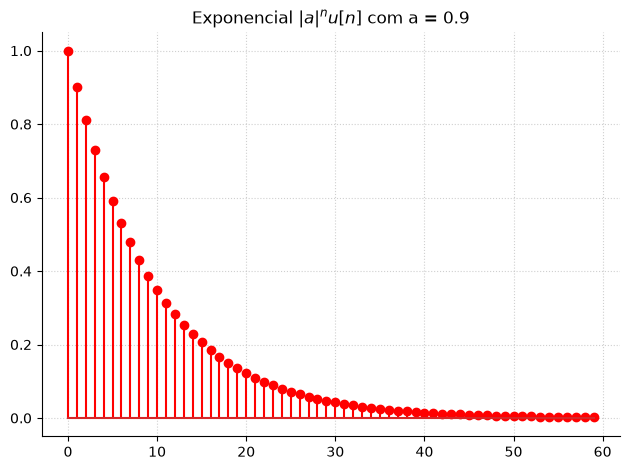

In [5]:
# 3. Exponencial
a  = 0.9
un = (n >= 0).astype(float)      # degrau u[n] (aqui n comeca em 0, entao e tudo 1)
yn = np.abs(a) ** n * un         # |a|^n * u[n]

fig, ax = plt.subplots()
ax.stem(n, yn, 'r')
ax.set_title(rf'Exponencial $|a|^n u[n]$ com a = {a}')
figureFormat(ax, fig, tight=True)
plt.show()

# Se |a| < 1 o sinal decai; se |a| > 1 ele cresce; se a for negativo o sinal alterna de sinal.

## Sinal aleatório - $x[n] = ?$

<div style="text-align: center;">
    <img src="./figures/random-Gaussian.png" alt="" width="500"/>
    <img src="./figures/random-uniform.png" alt="" width="500"/>
</div>


### Aleatório Gaussiano - $\mathcal{X} \sim \mathcal{N}(\mu, \sigma)$

<div style="text-align: center;">
    <img src="./figures/random-Gaussian-dist.png" alt="" width="500"/>
</div>


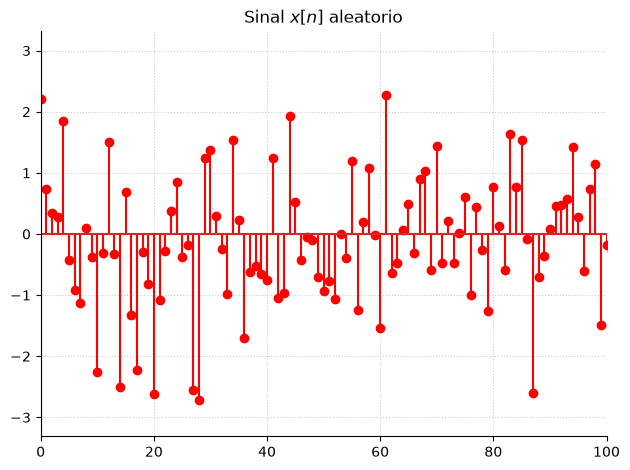

In [6]:
# 5. Sinal aleatorio (distribuicao Gaussiana)
N  = 1000
n  = np.arange(N)   # vetor de amostras

mu, sigma = 0, 1
xn = np.random.normal(mu, sigma, N)   # Gaussiano (normal): media 0, desvio padrao 1

# Plot
fig, ax = plt.subplots(1)
ax.stem(n, xn, 'ro')
plt.xlim([0, 100])
ax.set_title(r'Sinal $x[n]$ aleatorio')
figureFormat(ax, fig, tight=True)
plt.show()

Plote o **histograma** deste sinal.

**Dica:** Use `ax.hist`


In [7]:
# help(ax.hist)

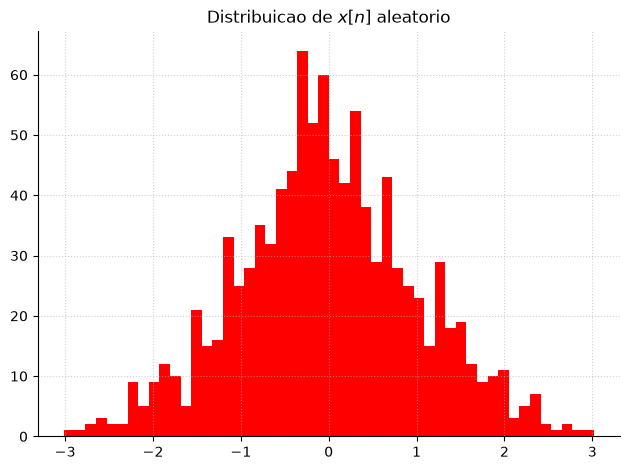

In [8]:
fig, ax = plt.subplots()
ax.hist(xn, 50, color='r')     # 50 caixas (bins)
ax.set_title(r'Distribuicao de $x[n]$ aleatorio')
figureFormat(ax, fig, tight=True)
plt.show()

# Formato de "sino": a maioria das amostras fica perto da media (0),
# e quase nada passa de +-3 desvios padrao.

### Aleatório uniforme - $\mathcal{X} \sim \mathcal{U} \{a, b\}$

<div style="text-align: center;">
    <img src="./figures/random-uniform-dist.png" alt="" width="500"/>
</div>


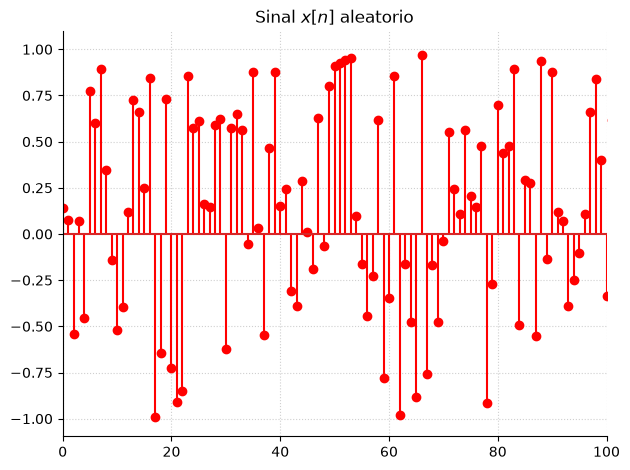

In [9]:
# 5. Sinal aleatorio (distribuicao uniforme)
N  = 1000
n  = np.arange(N)   # vetor de amostras

a, b = -1, 1
xn = np.random.uniform(a, b, N)   # uniforme entre -1 e 1

# Plot
fig, ax = plt.subplots(1)
ax.stem(n, xn, 'ro')
plt.xlim([0, 100])
ax.set_title(r'Sinal $x[n]$ aleatorio')
figureFormat(ax, fig, tight=True)
plt.show()

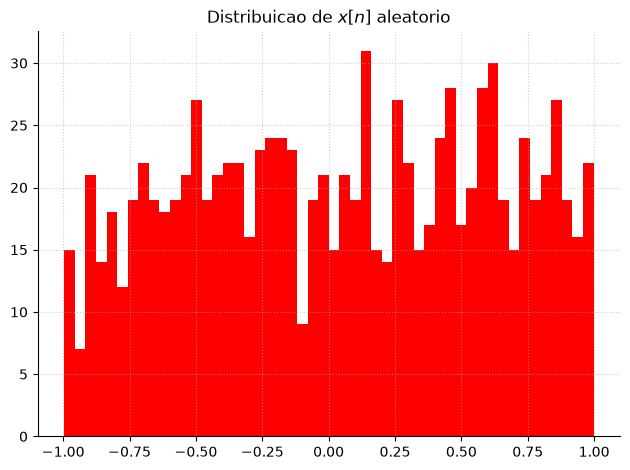

In [10]:
fig, ax = plt.subplots()
ax.hist(xn, 50, color='r')
ax.set_title(r'Distribuicao de $x[n]$ aleatorio')
figureFormat(ax, fig, tight=True)
plt.show()

# Agora o histograma fica "chapado": qualquer valor entre -1 e 1 tem a mesma chance.

## Minha biblioteca de sinais básicos

In [11]:
def SIGNALgenerate(N=100, signal='delta', params=None, k=0, a=0.9, P=10, phi=0):
    """
    Gera um sinal basico de N amostras.

    signal : 'delta', 'step', 'exp', 'osc' ou 'random'
    params : so para 'random': 'uniform' (senao usa Gaussiano)
    k      : atraso (shift) para delta, step e exp
    a      : base da exponencial
    P      : periodo (em amostras) da oscilacao
    phi    : fase da oscilacao
    """
    n = np.arange(N)

    if signal == 'delta':
        # Delta (impulse): d[n - k]
        x = np.zeros(N)
        x[k] = 1

    if signal == 'step':
        # Step: u[n - k]
        x = np.zeros(N)
        x[k:] = 1

    if signal == 'exp':
        # Exponential: |a|^(n-k) u[n-k]
        u = np.zeros(N)
        u[k:] = 1                          # degrau u[n - k]
        x = np.abs(a) ** (n - k) * u       # a exponencial so "liga" a partir de k

    if signal == 'osc':
        # Oscillation: sin(wo n + phi), com wo = 2 pi / P
        wo = 2 * np.pi / P
        x = np.sin(wo * n + phi)

    if signal == 'random':
        # Random
        if params == 'uniform':
            # Uniform
            x = np.random.uniform(-1, 1, N)
        else:
            # Gaussian
            x = np.random.normal(0, 1, N)

    return np.array(x)

In [12]:
def SIGNALdelay(x, n):
    """
    Slows a signal down by k samples
    (atrasa o sinal em n amostras, preenchendo o comeco com zeros)
    """
    result = np.zeros(len(x))
    result[n:] = x[:len(x) - n]   # x[n - k]: o que estava em 0 vai para n, e o fim e cortado

    return result

In [13]:
def SIGNALplot(x, title=None):
    fig, ax = plt.subplots()
    ax.stem(x, 'r')
    if title:
        ax.set_title(title)
    figureFormat(ax, fig, tight=True)
    plt.show()

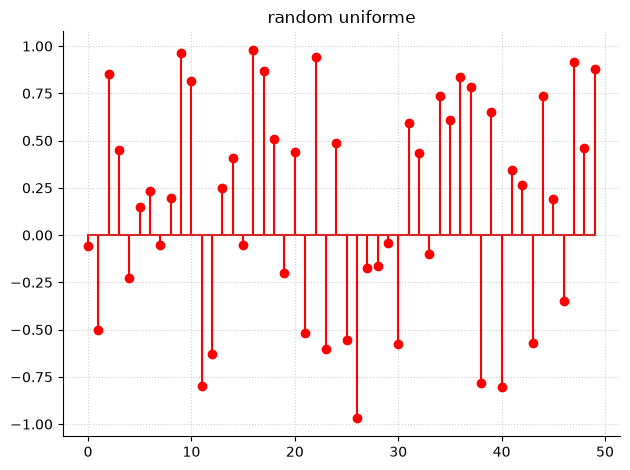

In [14]:
# Testando a biblioteca
SIGNALplot(SIGNALgenerate(50, 'random', 'uniform'), 'random uniforme')

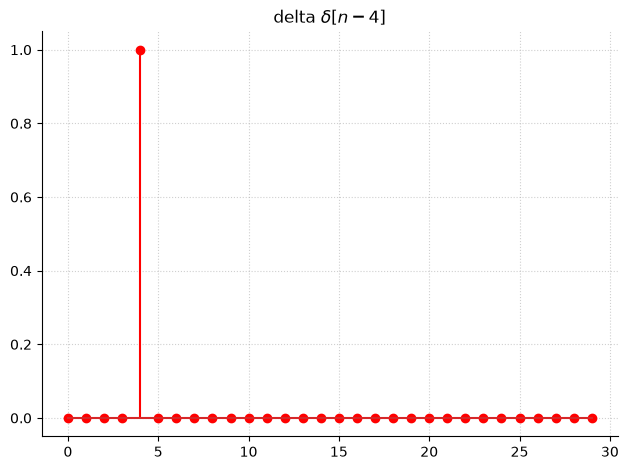

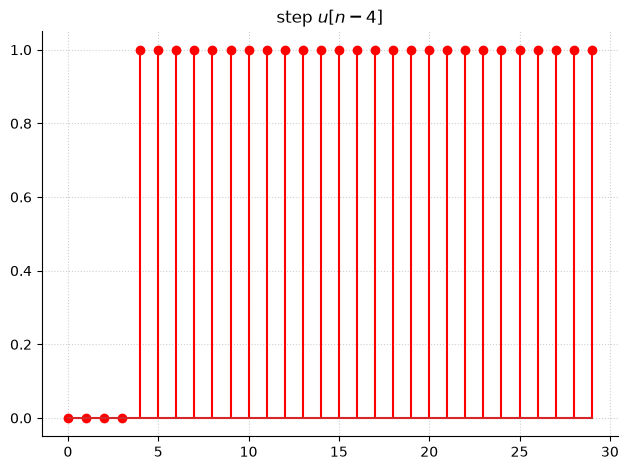

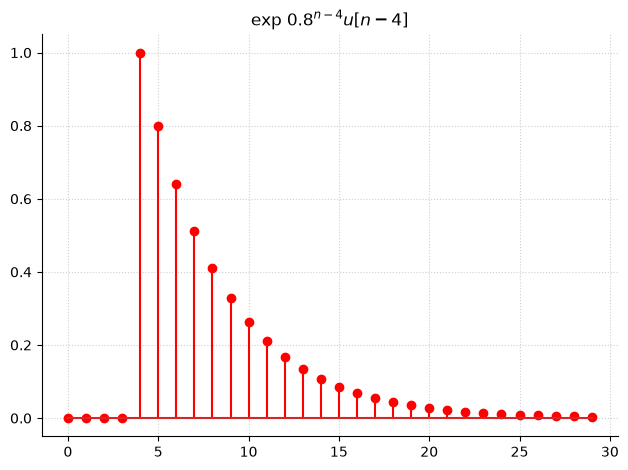

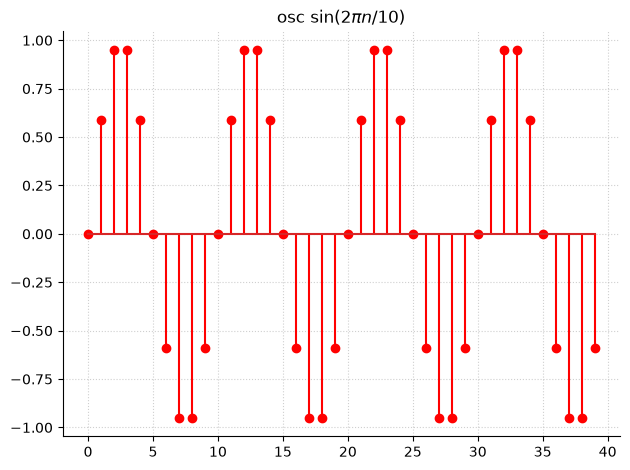

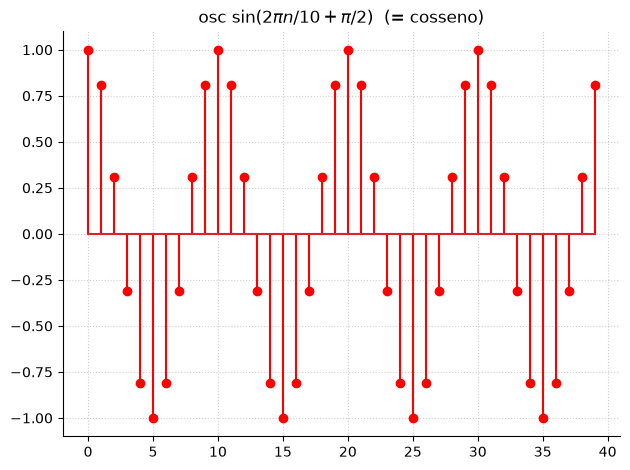

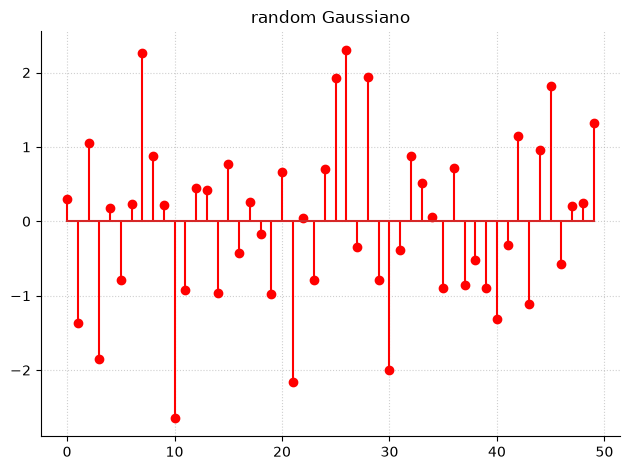

In [15]:
# Testando cada sinal da biblioteca
SIGNALplot(SIGNALgenerate(30, 'delta', k=4),                 r'delta $\delta[n-4]$')
SIGNALplot(SIGNALgenerate(30, 'step',  k=4),                 r'step $u[n-4]$')
SIGNALplot(SIGNALgenerate(30, 'exp',   a=0.8, k=4),          r'exp $0.8^{n-4} u[n-4]$')
SIGNALplot(SIGNALgenerate(40, 'osc',   P=10, phi=0),         r'osc $\sin(2\pi n/10)$')
SIGNALplot(SIGNALgenerate(40, 'osc',   P=10, phi=np.pi/2),   r'osc $\sin(2\pi n/10 + \pi/2)$  (= cosseno)')
SIGNALplot(SIGNALgenerate(50, 'random'),                     'random Gaussiano')

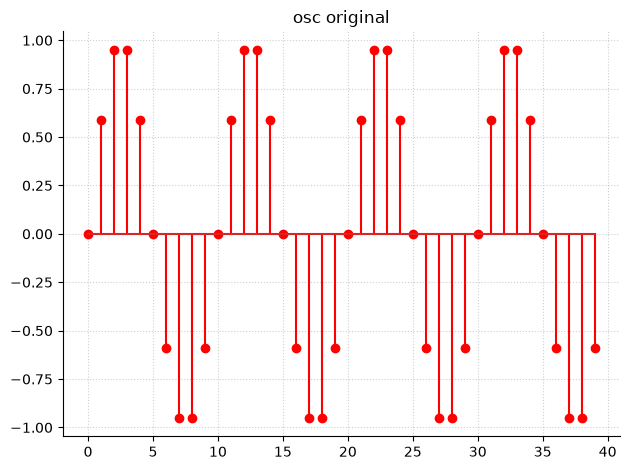

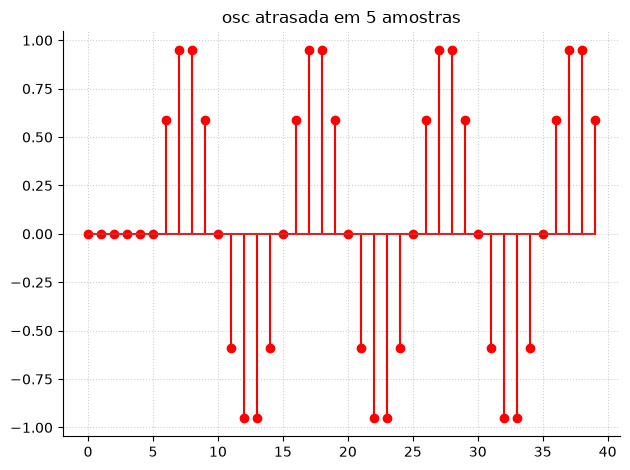

SIGNALdelay(delta, 7) == delta com k=7 ? True


In [16]:
# Testando o atraso: SIGNALdelay(x, k) deve dar o mesmo que gerar o sinal ja com k
x  = SIGNALgenerate(40, 'osc', P=10)
xd = SIGNALdelay(x, 5)

SIGNALplot(x,  'osc original')
SIGNALplot(xd, 'osc atrasada em 5 amostras')

# Conferindo com o delta: atrasar delta[n] em 7 = delta[n-7]
print('SIGNALdelay(delta, 7) == delta com k=7 ?',
      np.array_equal(SIGNALdelay(SIGNALgenerate(20, 'delta'), 7),
                     SIGNALgenerate(20, 'delta', k=7)))

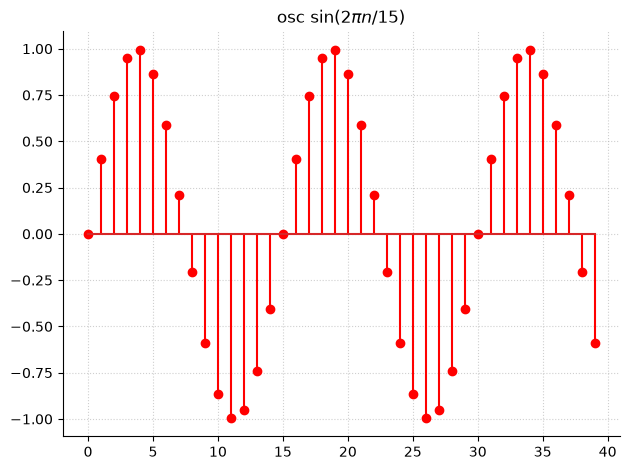

In [17]:
SIGNALplot(SIGNALgenerate(40, 'osc',   P=15),       r'osc $\sin(2\pi n/15)$')